## Name : Sulaiman Alfawzan

# M2.Ex2: Automobile Fuel Efficiency

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [1]:
import pandas as pd
import sklearn

## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [3]:
# pd.read_csv("../../../datasets/auto-mpg.csv")

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path('./Data/auto-mpg.csv')
print(DATA_PATH.resolve())
print(DATA_PATH.exists())
df = pd.read_csv(DATA_PATH)
df.head()

C:\Users\xxslo\OneDrive\Desktop\AAI-bootcamp\student\C3\M2\Data\auto-mpg.csv
True


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


### Step 2.a Assign variables `X` to the features and `y` to the target

In [13]:
x = df[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name']]
y = df['mpg']

### Step 2.b print the type of each

In [11]:
x.dtypes

cylinders         int64
displacement    float64
horsepower          str
weight            int64
acceleration    float64
model year        int64
origin            int64
dtype: object

In [12]:
y.dtype

dtype('float64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [ ]:
# Since the target y is numerical this is a regression.

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [14]:
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (398, 8)
y shape: (398,)


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [21]:
# Numerical
df[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']].describe()

,cylinders,displacement,weight,acceleration
count,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,2970.424623,15.568090
std,1.701004,104.269838,846.841774,2.757689
min,3.000000,68.000000,1613.000000,8.000000
25%,4.000000,104.250000,2223.750000,13.825000
50%,4.000000,148.500000,2803.500000,15.500000
75%,8.000000,262.000000,3608.000000,17.175000
max,8.000000,455.000000,5140.000000,24.800000


In [31]:
# Categorical
df[['model year', 'origin', 'car name']].describe()

,model year,origin
count,398.000000,398.000000
mean,76.010050,1.572864
std,3.697627,0.802055
min,70.000000,1.000000
25%,73.000000,1.000000
50%,76.000000,1.000000
75%,79.000000,2.000000
max,82.000000,3.000000


### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

In [32]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

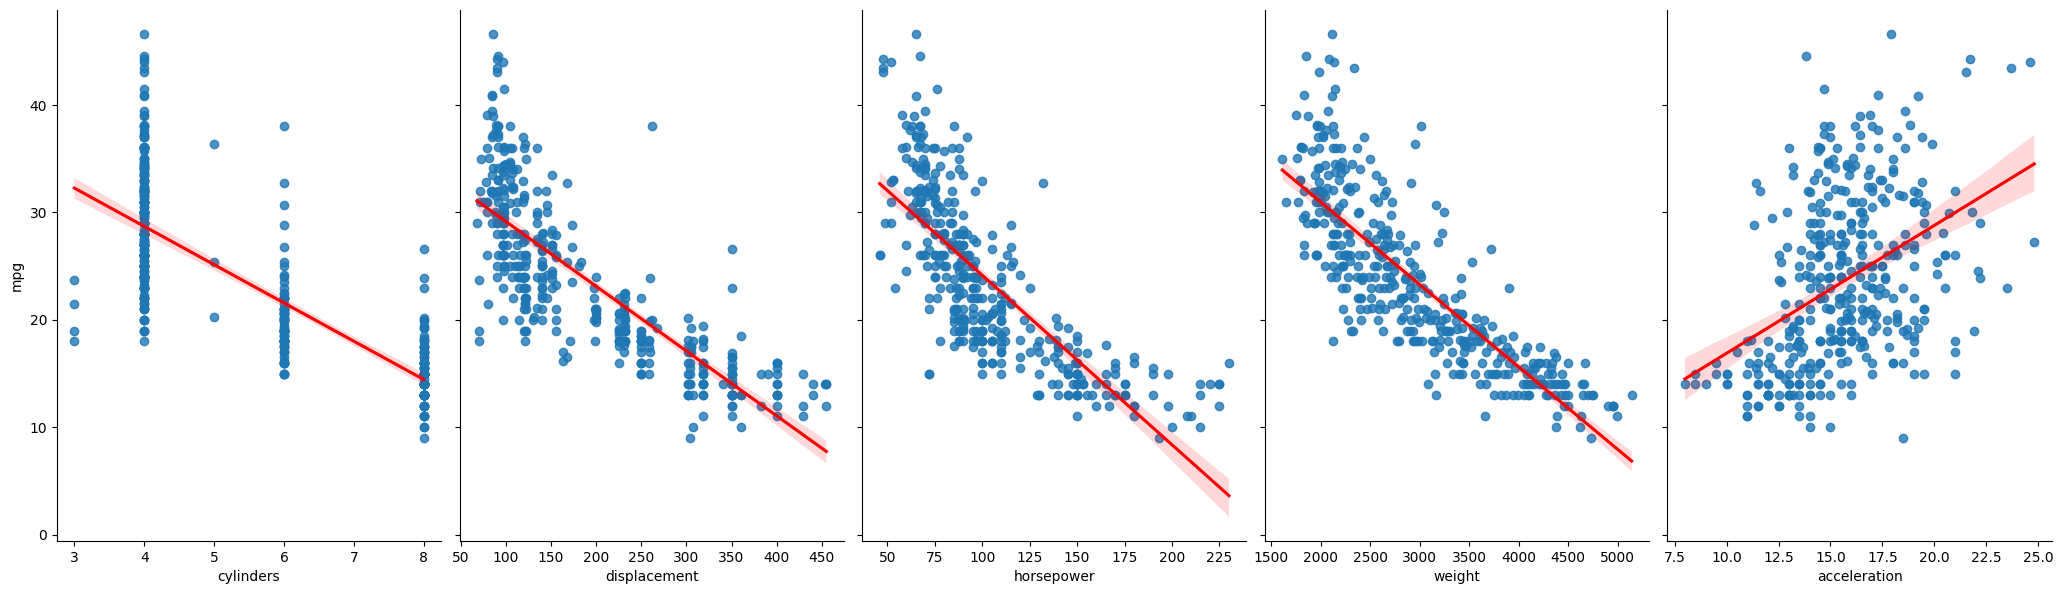

In [35]:
sns.pairplot(
    data=df,
    x_vars=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration'],
    y_vars='mpg',
    height=6,
    aspect=0.7,
    kind='reg',
    plot_kws={'line_kws':{'color':'red'}}
    )

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer





In [ ]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)

### Step 8. Split the dataset into train and test sets

### Step 9.a Fit the pipeline on the training set

In [ ]:
pipe.fit(X_train, y_train)

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

### Step 10. Evaluate the pipeline on the test set

In [ ]:
score = pipe.score(X_test, y_test)